In [ ]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [41]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [23]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi_and_pt,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_maskv2
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_maskv2(particles)
particles


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4099408 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...


event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
403,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[60, 61, … 5643]","[-511, 111, … -11]","[5.27958, 0.13498, … 0.000511]","[371.48999, 11.619555, … 0.139213]","[0.0, 0.0, … 1.0]","[-0.005285, -0.005285, … 715.556213]","[0.002104, 0.002104, … -553.697876]","[35.40321, 35.40321, … 3252.191895]","[-0.219061, -0.219061, … 11.088506]","[141.70224, 4.731999, … 0.00579]","[-13.754244, -0.33812, … -0.033486]","[343.086365, 10.606115, … 0.135]","[0.001583, 0.001722, … -793.363647]","[35.416374, 35.415329, … -3190.729004]","[1, 1, … 1]","[8, 8, … 5642]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[1.613221, 1.544319, … 2.088052]","[-0.096761, -0.071333, … -1.399581]","[142.36821, 4.744064, … 0.033983]"
534,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[116, 117, … 4651]","[223, 113, … 2212]","[0.788842, 0.788639, … 0.938272]","[628.063049, 478.189972, … 1.140818]","[0.0, 0.0, … 1.0]","[0.01892, 0.01892, … 1657.880127]","[-0.00057, -0.00057, … 1393.627075]","[-6.367845, -6.367845, … 1785.21875]","[0.175848, 0.175848, … 9.892393]","[-0.217436, 0.150439, … 0.0964]","[-0.324164, 0.864908, … 0.340285]","[628.062439, 478.188507, … 0.544082]","[0.0, 0.0, … -1215.253052]","[0.0, 0.0, … -972.667786]","[1, 1, … 1]","[8, 8, … 4650]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[8.07654, 6.993383, … 1.215856]","[-2.161627, 1.398582, … 1.294738]","[0.390334, 0.877894, … 0.353676]"
391,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[111, 112, … 6531]","[-213, 113, … 11]","[0.827543, 0.853139, … 0.000511]","[4.848463, 1.851389, … 0.000687]","[-1.0, 0.0, … -1.0]","[0.0009, 0.0009, … -492.235382]","[0.01907, 0.01907, … 84.110062]","[-11.466556, -11.466556, … 777.377258]","[0.017455, 0.017455, … 8.172297]","[-2.90281, -1.005228, … 0.000457]","[-3.772497, -1.227662, … -0.000004]","[0.405867, 0.426798, … -0.000047]","[-0.010916, -0.011385, … NaN]","[-11.46522, -11.462433, … NaN]","[1, 1, … 1]","[8, 8, … 6528]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[0.085162, 0.265841, … -0.1016]","[-2.22664, -2.256905, … -0.007683]","[4.760046, 1.586707, … 0.000457]"
528,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[98, 99, … 5498]","[111, 221, … -11]","[0.13498, 0.54785, … 0.000511]","[539.077454, 1009.403076, … 0.167027]","[0.0, 0.0, … 1.0]","[0.012049, 0.012049, … 445.570648]","[0.003532, 0.003532, … 12.138778]","[69.298874, 69.298874, … 3215.398926]","[-0.24438, -0.24438, … 10.354676]","[0.162964, -0.32564, … 0.022914]","[-0.035262, -0.141302, … 0.001382]","[-539.077393, -1009.402893, … 0.165441]","[0.0, 0.0, … -376.604095]","[0.0, 0.0, … -3810.282471]","[1, 1, … 1]","[9, 9, … 5496]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[-8.774089, -8.646221, … 2.67299]","[-0.213094, -2.732191, … 0.060234]","[0.166735, 0.354975, … 0.022955]"
784,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[45, 46, … 7558]","[-523, 3212, … 11]","[5.3252, 1.19264, … 0.000511]","[77.910278, 2.961131, … 0.13791]","[0.0, 0.0, … -1.0]","[-0.000049, -0.000049, … 633.873657]","[-0.015847, -0.015847, … 43.325043]","[-110.292137, -110.292137, … -3201.562988]","[-0.010545, -0.010545, … 10.516368]","[-1.092153, -0.380331, … 0.023609]","[-40.645164, -1.845223, … 0.000914]","[-66.245239, -1.948437, … -0.13587]","[0.000377, 0.003151, … NaN]","[-110.266327, -

In [40]:
(particles
 .select(['event_id','particle_id', 'has_track', 'is_target_particle', 'pt', 'eta'])
 .explode('particle_id', 'has_track', 'is_target_particle', 'pt', 'eta')
 .filter((pl.col('has_track')) 
         & (pl.col('pt')>0.5) & (pl.col('eta').abs()<3.5)
         ))

event_id,particle_id,has_track,is_target_particle,pt,eta
u32,u64,bool,bool,f32,f32
403,68,true,true,1.859402,1.806727
403,111,true,false,0.864009,-1.128131
403,203,true,false,0.922678,-1.726148
403,214,true,true,1.288258,-0.860153
403,223,true,true,50.908745,1.637618
…,…,…,…,…,…
86,2298,true,true,1.141452,-2.724512
86,2489,true,true,1.826882,-2.6264
86,3171,true,true,2.567591,-2.675356


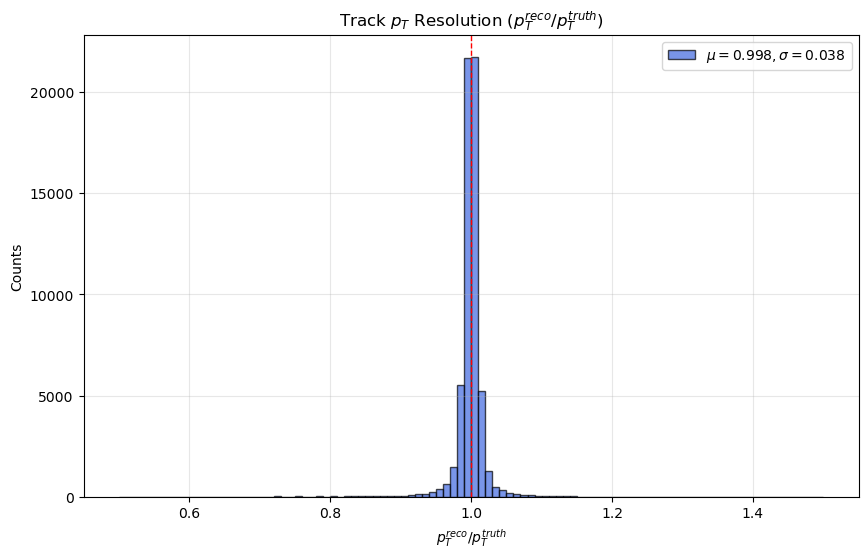

In [38]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

def plot_pt_resolution(particles_df: pl.DataFrame, tracks_df: pl.DataFrame):
    # -------------------------------------------------------------------------
    # 1. Prepare Truth (Particles)
    # -------------------------------------------------------------------------
    # We select only the necessary columns and flatten the lists
    q_particles = (
        particles_df.lazy()
        .select([
            pl.col("event_id"),
            pl.col("particle_id"),
            pl.col("pt").alias("pt_truth") # Rename to distinguish from track pt
        ])
        .explode(["particle_id", "pt_truth"])
       # .set_sorted(["event_id", "particle_id"]) # Optimization for join
    )

    # -------------------------------------------------------------------------
    # 2. Prepare Reco (Tracks) & Calculate Track Pt
    # -------------------------------------------------------------------------
    # Pt = p * sin(theta) = |1/qop| * sin(theta)
    q_tracks = (
        tracks_df.lazy()
        .select([
            pl.col("event_id"),
            pl.col("majority_particle_id"), # This links to particle_id
            pl.col("qop"),
            pl.col("theta")
        ])
        .explode(["majority_particle_id", "qop", "theta"])
        .with_columns([
            # Safe calculation of Track Pt (avoid div by zero)
            (1.0 / pl.col("qop").abs().replace(0.0, 1e-9) * pl.col("theta").sin())
            .alias("pt_reco")
        ])
    )

    # -------------------------------------------------------------------------
    # 3. Join & Calculate Ratio
    # -------------------------------------------------------------------------
    # Inner join filters out tracks that don't match a recorded truth particle
    # (e.g. fakes or secondaries not in the particle list)
    q_joined = (
        q_tracks.join(
            q_particles,
            left_on=["event_id", "majority_particle_id"],
            right_on=["event_id", "particle_id"],
            how="inner"
        )
        .select([
            pl.col("pt_reco"),
            pl.col("pt_truth"),
            (pl.col("pt_reco") / pl.col("pt_truth")).alias("pt_ratio")
        ])
    )

    # Execute Query
    df_res = q_joined.collect()

    # -------------------------------------------------------------------------
    # 4. Do Histogram
    # -------------------------------------------------------------------------
    ratio_data = df_res["pt_ratio"].to_numpy()
    
    # Filter insane outliers for plotting (keep 0.0 to 2.0)
    # Ideally the peak is exactly at 1.0
    valid_mask = (ratio_data > 0.0) & (ratio_data < 3.0)
    filtered_data = ratio_data[valid_mask]

    plt.figure(figsize=(10, 6))
    
    # Statistics
    mu = np.mean(filtered_data)
    sigma = np.std(filtered_data)
    
    plt.hist(filtered_data, bins=100, range=(0.5, 1.5), 
             alpha=0.7, color='royalblue', edgecolor='black', 
             label=f'$\\mu={mu:.3f}, \\sigma={sigma:.3f}$')
    
    plt.axvline(1.0, color='red', linestyle='dashed', linewidth=1)
    plt.title("Track $p_T$ Resolution ($p_{T}^{reco} / p_{T}^{truth}$)")
    plt.xlabel("$p_{T}^{reco} / p_{T}^{truth}$")
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df_res

# Example usage (assuming you have the dataframes loaded)
df_ratios = plot_pt_resolution(particles, tracks)

In [47]:
from primary.preprocessing import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, tracks=tracks, calo_hits=calo_hits, num_of_events=100, pt_cut=1, eta_cut=3.0)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 433815 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 100 events. Time: 0.09s
Workload optimized: 100 events merged into 100 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 29.23s
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 15 iterations.
Step 4: Final validation...


In [45]:
calo_hits

event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]]
0,"[14, 11, … 11]","[0.001968, 0.000626, … 0.000133]","[-319.95813, -180.72757, … -99.622643]","[-235.105301, -356.353302, … -307.14505]","[4514.5, 3242.800049, … 3252.899902]","[[1009, 1010, … 1046], [917, 915], … [976]]","[[0.000357, 0.000102, … 0.000504], [0.000476, 0.00015], … [0.000133]]","[[14.921773, 14.915427, … 14.947093], [10.852165, 10.768022], … [10.706934]]"
1,"[10, 9, … 10]","[0.00007, 0.000226, … 0.000199]","[-255.0, -200.717987, … 15.3]","[-1302.900024, -364.633606, … 1267.550049]","[-1836.0, -3374.100098, … -861.900024]","[[1144], [2867], … [2325]]","[[0.00007], [0.000226], … [0.000199]]","[[8.069325], [11.934299], … [5.520046]]"
2,"[9, 10, … 9]","[0.00016, 0.000609, … 0.000857]","[-624.59021, -1307.949951, … -1006.558716]","[319.435944, 127.5, … -847.883911]","[-3268.050049, 351.899994, … -3268.050049]","[[1666], [2966, 3018], … [2335]]","[[0.00016], [0.000538, 0.00007], … [0.000857]]","[[11.347424], [4.571045, 4.587587], … [12.148624]]"
3,"[11, 9, … 10]","[0.000141, 0.000435, … 0.000653]","[296.96283, 173.399994, … -777.393188]","[-490.373688, -887.988953, … -993.767883]","[3313.5, -3303.399902, … 2861.100098]","[[3360], [656], … [1317]]","[[0.000141], [0.000435], … [0.000653]]","[[11.276829], [11.554907], … [10.170697]]"
4,"[11, 10, … 10]","[0.000199, 0.000092, … 0.000146]","[-243.458908, 1101.495605, … 1234.614624]","[-374.530731, -762.508606, … 384.429535]","[3242.800049, 1116.900024, … 2529.600098]","[[1876], [2192], … [1957]]","[[0.000199], [0.000092], … [0.000146]]","[[12.287476], [5.514093], … [9.358251]]"
…,…,…,…,…,…,…,…,…
995,"[10, 9, … 10]","[0.000179, 0.000755, … 0.002765]","[1240.377441, 251.265656, … -1015.369995]","[-436.498352, -393.377869, … 762.932861]","[923.099976, -3283.199951, … -2009.400024]","[[2253], [3423], … [4697, 4699, 4696]]","[[0.000179], [0.000755], … [0.000426, 0.000578, 0.001761]]","[[5.130617], [10.436249], … [7.334979, 7.338215, 7.337309]]"
996,"[9, 9, … 9]","[0.001676, 0.000216, … 0.001685]","[153.403976, 231.21611, … 494.277039]","[290.388306, 252.853577, … 287.539246]","[-3364.0, -3374.100098, … -3278.149902]","[[3716], [4874, 4899], … [3983, 3981, … 3987]]","[[0.001676], [0.00003, 0.000187], … [0.000137, 0.000351, … 0.00073]]","[[12.006806], [11.732627, 11.585358], … [11.363146, 11.363526, … 11.363279]]"
997,"[11, 11, … 12]","[0.000172, 0.002722, … 0.000511]","[-590.129578, -251.657959, … -1352.489136]","[349.323486, -580.902161, … 180.0]","[3313.5, 3298.350098, … -3851.5]","[[7933], [3159, 4558, … 6124], … [6785]]","[[0.000172], [0.000129, 0.000042, … 0.001454], … [0.000511]]","[[11.654412], [11.277998, 11.386529, … 11.263212], … [14.255626]]"


In [48]:
df_deps=preprocessed['target_particles_deps']
df_particles=preprocessed['target_particles']
df_clusters=preprocessed['calo_clusters']
df_tracks=preprocessed['tracks']

In [49]:
df_clusters

event_id,cluster_id,total_cluster_energy,hcal_energy,topo_sigma_eta,topo_sigma_phi,topo_sigma_rho,cluster_cx,cluster_cy,cluster_cz,cluster_phi,cluster_eta,hcal_fraction
u32,list[i32],list[f64],list[f64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f64]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[0.0, 0.0, … 0.012899]","[0.01673, 0.036442, … 0.0]","[0.022366, 0.028642, … 0.0]","[47.981728, 60.55558, … 0.0]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]","[-1.505896, 0.874787, … -2.908992]","[1.687719, -0.214194, … 1.352489]","[0.0, 0.0, … 1.0]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[0.0, 0.0, … 0.034808]","[0.016922, 0.042009, … 0.0]","[0.021009, 0.060175, … 0.0]","[52.333401, 48.167, … 0.0]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]","[-1.781798, -1.043302, … 2.535081]","[-1.10054, -2.008766, … 0.010466]","[0.0, 0.0, … 1.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[0.0, 0.0, … 0.033052]","[0.024936, 0.032155, … 0.0]","[0.40881, 0.038473, … 0.0]","[42.924919, 81.917564, … 0.0]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]","[3.057412, -2.035884, … 2.926595]","[0.244793, -1.473731, … 0.41516]","[0.0, 0.0, … 1.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[0.0, 0.0, … 0.015514]","[0.039802, 0.027216, … 0.0]","[0.047512, 0.052917, … 0.0]","[61.017933, 47.577705, … 0.0]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]","[2.182628, -0.409989, … -2.79643]","[0.307553, -0.241523, … 1.174939]","[0.0, 0.0, … 1.0]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[0.0, 0.0, … 0.024687]","[0.021042, 0.021785, … 0.0]","[0.044711, 0.022532, … 0.0]","[75.211868, 51.0546, … 0.0]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]","[-0.575668, 1.02751, … 2.778817]","[0.755694, 0.559448, … 0.337621]","[0.0, 0.0, … 1.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…
95,"[0, 1, … 617]","[66.242444, 72.488217, … 0.78129]","[0.0, 0.0, … 0.78129]","[0.119548, 0.03534, … 0.0]","[0.180629, 0.032888, … 0.0]","[64.226357, 57.559361, … 0.0]","[-334.895905, 321.225037, … -2202.310791]","[-215.548737, -1292.880737, … -587.509338]","[-3305.510254, 1501.251709, … 1620.0]","[-2.569709, -1.327271, … -2.880894]","[-2.81298, 0.968326, … 0.661439]","[0.0, 0.0, … 1.0]"
96,"[0, 1, … 840]","[115.692938, 75.688911, … 0.034788]","[0.0, 0.0, … 0.034788]","[0.024023, 0.033609, … 0.0]","[0.042013, 0.048182, … 0.0]","[56.236202, 65.448219, … 0.0]","[-846.895569, 784.731628, … -2475.934326]","[-1037.897461, 1089.703979, … -2306.22876]","[643.532349, -762.927063, … 1740.0]","[-2.255201, 0.946686, … -2.391667]","[0.463613, -0.541312, … 0.493913]","[0.0, 0.0, … 1.0]"
97,"[0, 1, … 991]","[1230.503656, 494.178099, … 0.052503]","[0.0, 0.0, … 0.052503]","[0.100916, 0.04146, … 0.0]","[2.303145, 0.062399, … 0.0]","[59.972599, 61.263042, … 0.0]","[-401.495972, 688.888123, … -2412.5]","[40.472782, -416.98941, … -60.0]","[-3335.438477, -3323.664062, … 630.0]","[3.041127, -0.544313, … -3.116727]","[-2.808893, -2.125165, … 0.258181]","[0.0, 0.0, … 1.0]"


In [70]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]"
…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]"


In [43]:
n_tracks = df_tracks.select(pl.col("track_id").list.len()).to_series().to_numpy()
n_clusters = df_clusters.select(pl.col("cluster_id").list.len()).to_series().to_numpy()
n_particles = df_particles.select(pl.col("particle_id").list.len()).to_series().to_numpy()
n_deps = df_deps.select(pl.col("particle_idx").list.len()).to_series().to_numpy()

In [48]:
n_clusters

array([331, 415, 594, 714, 485, 867, 961, 845, 586, 920], dtype=uint32)

In [46]:
# 3. Filter Events
# ---------------------------------------------------------------------
n_nodes = n_tracks + n_clusters
mask = (n_nodes < 3000) & (n_particles < 300)

print(f"Total events: {len(mask)}")
print(f"Removing {(~mask).sum()} events with too many nodes or particles")

Total events: 10
Removing 0 events with too many nodes or particles


In [35]:
df_tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id,phi_int,eta_int,track_tanlambda,track_omega,phi_int_right,eta_int_right,track_tanlambda_right,track_omega_right
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]","[-0.659648, 2.10528, … -0.823465]","[-0.000471, 0.000699, … 0.000907]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]","[-0.659648, 2.10528, … -0.823465]","[-0.000471, 0.000699, … 0.000907]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]"
5,"[-0.003103, -0.008347, … -0.015018]","[-38.151382, -38.37936, … -38.262405]","[-2.975606, -2.86293, … 2.873475]","[2.771352, 0.488045, … 0.741196]","[0.172809, -0.262056, … 0.115564]","[184, 953, … 847]","[[4671, 4670, … 424], [5665, 5666, … 438], … [5208, 5215, … 410]]","[0, 1, … 63]","[2.839095, -2.312793, … 2.706912]","[-1.696386, 1.384927, … 0.922067]","[-2.57639, 1.883668, … 1.092557]","[0.00043, -0.000503, … 0.000154]","[2.839095, -2.312793, … 2.706912]","[-1.696386, 1.384927, … 0.922067]","[-2.57639, 1.883668, … 1.092557]","[0.00043, -0.000503, … 0.000154]"
6,"[-0.139306, 0.030785, … 0.058325]","[-2.267007, -1.712351, … -1.685506]","[-3.014295, -2.940904, … 3.031545]","[2.892523, 2.801454, … 2.638982]","[0.20807, 0.430545, … -0.

In [5]:
target_particles = preprocessed['target_particles']
truth_particles = preprocessed['truth_particles']
calo_clusters = preprocessed['calo_clusters']
tracks = preprocessed['tracks']

In [50]:
calo_clusters

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
5,"[0, 1, … 866]","[56.867899, 31.121075, … 0.028071]","[-165.041275, -1268.863892, … -2155.192871]","[358.53891, 347.2724, … 567.992493]","[3326.897949, 1293.914673, … -3240.0]"
6,"[0, 1, … 961]","[83.598469, 70.526036, … 0.119777]","[-244.706863, -268.75415, … -1661.053467]","[-239.107132, -671.726868, … 428.256714]","[-3333.455078, -3305.769287, … 2040.0]"
7,"[0, 1, … 844]","[273.347295, 181.332376, … 0.01218]","[-352.664215, 55.095375, … -2325.486816]","[-77.463295, -1249.410645, … -1223.022339]","[-3335.097656, 3325.908447, … 3450.0]"
8,"[0, 1, … 585]","[346.705919, 122.993727, … 0.038514]","[-388.283386, 839.877502, … -1915.905884]","[1274.554565, -1190.164673, … -2000.758667]","[-1374.43042, -4.05305, … -1680.0]"


In [51]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import add_eta_and_phi_and_pt
from primary.preprocessing import set_target_particles_maskv2
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3, add_ms_cluster_labels
calo = calo_hits.filter(pl.col('event_id')< 100)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi_and_pt(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo)
particles = set_target_particles_maskv2(particles)
# apply cu

calo = add_ms_cluster_labels(calo, bandwidth=120.0)

Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 433815 depositors.
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 3 iterations.
Step 4: Final validation...
--- Starting Optimized 3D Clustering (MeanShift, bw=120.0) ---
Data prepared: 100 events. Time: 0.07s
Workload optimized: 100 events merged into 100 tasks.
Largest batch processing first (LPT scheduling).
Aggregating results...
Done. Total time: 29.56s


In [63]:
cells_clust =(calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.sort(['event_id', 'detector', 'cluster_id'])
.join(
    ((calo.select(['event_id', 'cluster_id', 'detector'])
.explode(['cluster_id', 'detector'])
.group_by(['event_id', 'detector', 'cluster_id'])
.agg([pl.count().alias('n_cells')])
.group_by(['event_id', 'cluster_id'])
.agg([pl.count().alias('n_detectors')])
.sort(['n_detectors'], descending=True)
.filter(pl.col('n_detectors')>1)
)),
on=['event_id', 'cluster_id'],
how='inner'
)
)


/tmp/ipykernel_885261/1940663240.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1940663240.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


In [65]:
cells_clust['n_cells'].sum()

24659

In [68]:
calo.select('x').explode('x')

x
f32
-319.95813
-180.72757
-251.553864
-172.447266
574.516541
…
1054.826538
1116.081299
-165.032837


/tmp/ipykernel_885261/1102950304.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_cells')])
/tmp/ipykernel_885261/1102950304.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias('n_detectors')])


event_id,cluster_id,n_detectors
u32,i32,u32
24,421,2
67,96,2
90,108,2
10,675,2
27,299,2
…,…,…
76,726,2
46,395,2
24,241,2


In [49]:
# write preprocessed data to local disk as parquets
file_path = "/storage/agrp/barakma/PileupODD/data"
for key, df in preprocessed.items():
    df.write_parquet(f"{file_path}/{key}.parquet")

In [10]:
# try to see if i can load one of them
cl=pl.read_parquet(f"{file_path}/preprocessed_calo_clusters.parquet")
cl

event_id,cluster_id,total_cluster_energy,cluster_cx,cluster_cy,cluster_cz
u32,list[i32],list[f64],list[f32],list[f32],list[f32]
0,"[0, 1, … 330]","[117.038543, 13.86953, … 0.012899]","[82.099648, 862.302429, … -2929.909912]","[-1263.230957, 1032.093506, … -694.060181]","[3305.375977, -290.279144, … 5432.5]"
1,"[0, 1, … 414]","[127.071303, 65.037671, … 0.034808]","[-279.106384, 453.047211, … -2355.019043]","[-1303.080688, -777.688049, … 1633.770264]","[-1781.132812, -3294.084961, … 30.0]"
2,"[0, 1, … 593]","[59.975367, 47.772519, … 0.033052]","[-1330.139282, -608.895935, … -1989.682617]","[112.237022, -1213.421143, … 434.49231]","[330.038788, -2807.855225, … 870.0]"
3,"[0, 1, … 713]","[48.13458, 45.11502, … 0.015514]","[-784.961243, 1231.401367, … -2376.398193]","[1118.737671, -535.188843, … -854.449219]","[426.975983, -327.448303, … 3698.5]"
4,"[0, 1, … 484]","[46.673636, 14.84895, … 0.024687]","[1125.668335, 707.334534, … -1874.877563]","[-730.552307, 1171.266846, … 711.656189]","[1113.420532, 806.041016, … 690.0]"
…,…,…,…,…,…
95,"[0, 1, … 617]","[66.242444, 72.488217, … 0.78129]","[-334.895905, 321.225037, … -2202.310791]","[-215.548737, -1292.880737, … -587.509338]","[-3305.510254, 1501.251709, … 1620.0]"
96,"[0, 1, … 840]","[115.692938, 75.688911, … 0.034788]","[-846.895569, 784.731628, … -2475.934326]","[-1037.897461, 1089.703979, … -2306.22876]","[643.532349, -762.927063, … 1740.0]"
97,"[0, 1, … 991]","[1230.503656, 494.178099, … 0.052503]","[-401.495972, 688.888123, … -2412.5]","[40.472782, -416.98941, … -60.0]","[-3335.438477, -3323.664062, … 630.0]"


In [ ]:
tr

'/storage/agrp/barakma/PileupODD'

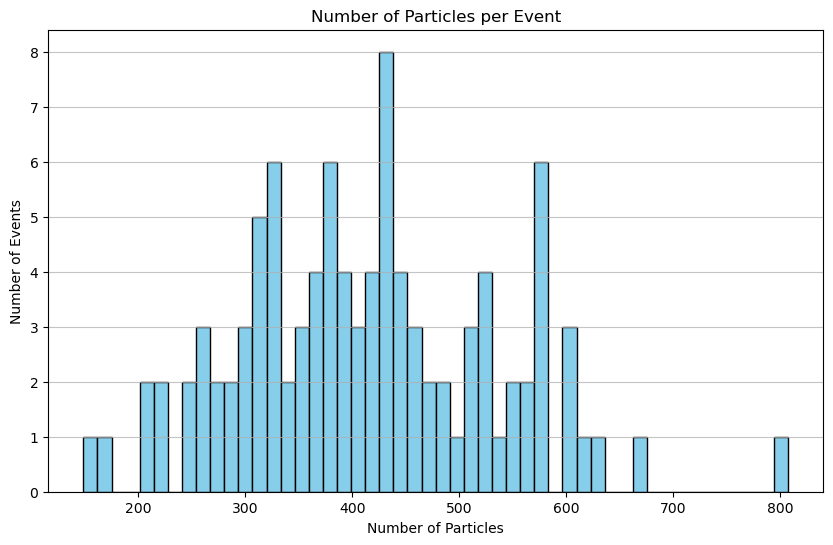

In [9]:
import matplotlib.pyplot as plt

# Calculate number of particles per event from target_particles
# particle_id is a list[u64], so we take the length of the list for each event
n_particles = target_particles["particle_id"].list.len()

plt.figure(figsize=(10, 6))
plt.hist(n_particles, bins=50, color='skyblue', edgecolor='black')
plt.title('Number of Particles per Event')
plt.xlabel('Number of Particles')
plt.ylabel('Number of Events')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Explode the energy list to get individual particle energies
particle_energies = target_particles["energy"].explode()

plt.figure(figsize=(10, 6))
plt.hist(particle_energies, bins=100, color='salmon', edgecolor='black')
plt.title('Target Particle Energy Distribution')
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of Particles')
plt.yscale('log') # Using log scale as energy distributions often span orders of magnitude
plt.grid(axis='y', alpha=0.75)
plt.show()